In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.cm as cm
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings("ignore")


In [39]:
df = pd.read_csv('data/g2g_emissions.csv')

In [40]:
display(df.sample(5))
display(df.info())

#df['FOCUS_TYPE'].value_counts()
df = df.drop( columns = ('FOCUS_TYPE'))

df['CO2_KG'] = df['CO2_TONS'] * 1000
df = df.drop(columns = 'CO2_TONS')


df["DATE"] = pd.to_datetime(
    df["YEAR"].astype(str) + "-" + df["MONTH"].astype(str).str.zfill(2) + "-01")

,LEVEL,AREA,FOCUS_TYPE,YEAR,MONTH,MARKET_SEGMENT,FLIGHT_TYPE,FLIGHT_PHASE,NB_FLIGHTS,CO2_TONS,NOX_KG,SOX_KG
168485,STATE,DE,AREA FOCUS,2022,1,business,D,climb,3083,741.6,2403.94,195.29
49473,NETWORK,FLYING_GREEN,AREA FOCUS,2020,3,cargo,A,descent,4279,8440.0,33590.89,2249.22
24269,NETWORK,EEA,AREA FOCUS,2019,6,lowcost,D,taxi-out,58010,26193.0,36040.00,6992.52
25928,NETWORK,EEA,AREA FOCUS,2020,9,cargo,A,descent,6579,9095.8,34689.64,2424.23
1698,NETWORK,ECAC,AREA FOCUS,2020,4,business,I,taxi-in,11003,313.8,212.50,82.26


<class 'pandas.DataFrame'>
RangeIndex: 511627 entries, 0 to 511626
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LEVEL           511627 non-null  str    
 1   AREA            511627 non-null  str    
 2   FOCUS_TYPE      511627 non-null  str    
 3   YEAR            511627 non-null  int64  
 4   MONTH           511627 non-null  int64  
 5   MARKET_SEGMENT  511627 non-null  str    
 6   FLIGHT_TYPE     511627 non-null  str    
 7   FLIGHT_PHASE    511627 non-null  str    
 8   NB_FLIGHTS      511627 non-null  int64  
 9   CO2_TONS        511627 non-null  float64
 10  NOX_KG          511627 non-null  float64
 11  SOX_KG          511627 non-null  float64
dtypes: float64(3), int64(3), str(6)
memory usage: 46.8 MB


None

In [41]:
df.duplicated().value_counts()
df = df.drop_duplicates()

In [42]:
df_state = df[df['LEVEL'] == 'STATE']
df_net = df[df['LEVEL'] == 'NETWORK']

df_state.to_csv('data/clean/emission_state_clean.csv', index=False)
df_net.to_csv('data/clean/emission_network_clean.csv', index=False)

---
---

In [43]:
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "#F7F7F5",
    "axes.facecolor":   "#F7F7F5",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#DDDDDD",
    "grid.linewidth":   0.6,
    "font.family":      "monospace",
    "axes.titlesize":   11,
    "axes.labelsize":   10,
})

# Country code → name mapping (for readable labels)
CODE2NAME = {
    "AL":"Albania","AM":"Armenia","AT":"Austria","AZ":"Azerbaijan",
    "BA":"Bosnia","BE":"Belgium","BG":"Bulgaria","CH":"Switzerland",
    "CY":"Cyprus","CZ":"Czechia","DE":"Germany","DK":"Denmark",
    "EE":"Estonia","ES":"Spain","FI":"Finland","FR":"France",
    "GB":"UK","GE":"Georgia","GR":"Greece","HR":"Croatia",
    "HU":"Hungary","IE":"Ireland","IL":"Israel","IS":"Iceland",
    "IT":"Italy","LT":"Lithuania","LU":"Luxembourg","LV":"Latvia",
    "MA":"Morocco","MD":"Moldova","ME":"Montenegro","MK":"N.Macedonia",
    "MT":"Malta","NL":"Netherlands","NO":"Norway","PL":"Poland",
    "PT - Lisbon FIR":"Portugal","PT - Santa Maria FIR":"PT Azores",
    "RO":"Romania","RS":"Serbia","SE":"Sweden","SI":"Slovenia",
    "SK":"Slovakia","TR":"Turkey","UA":"Ukraine"
}

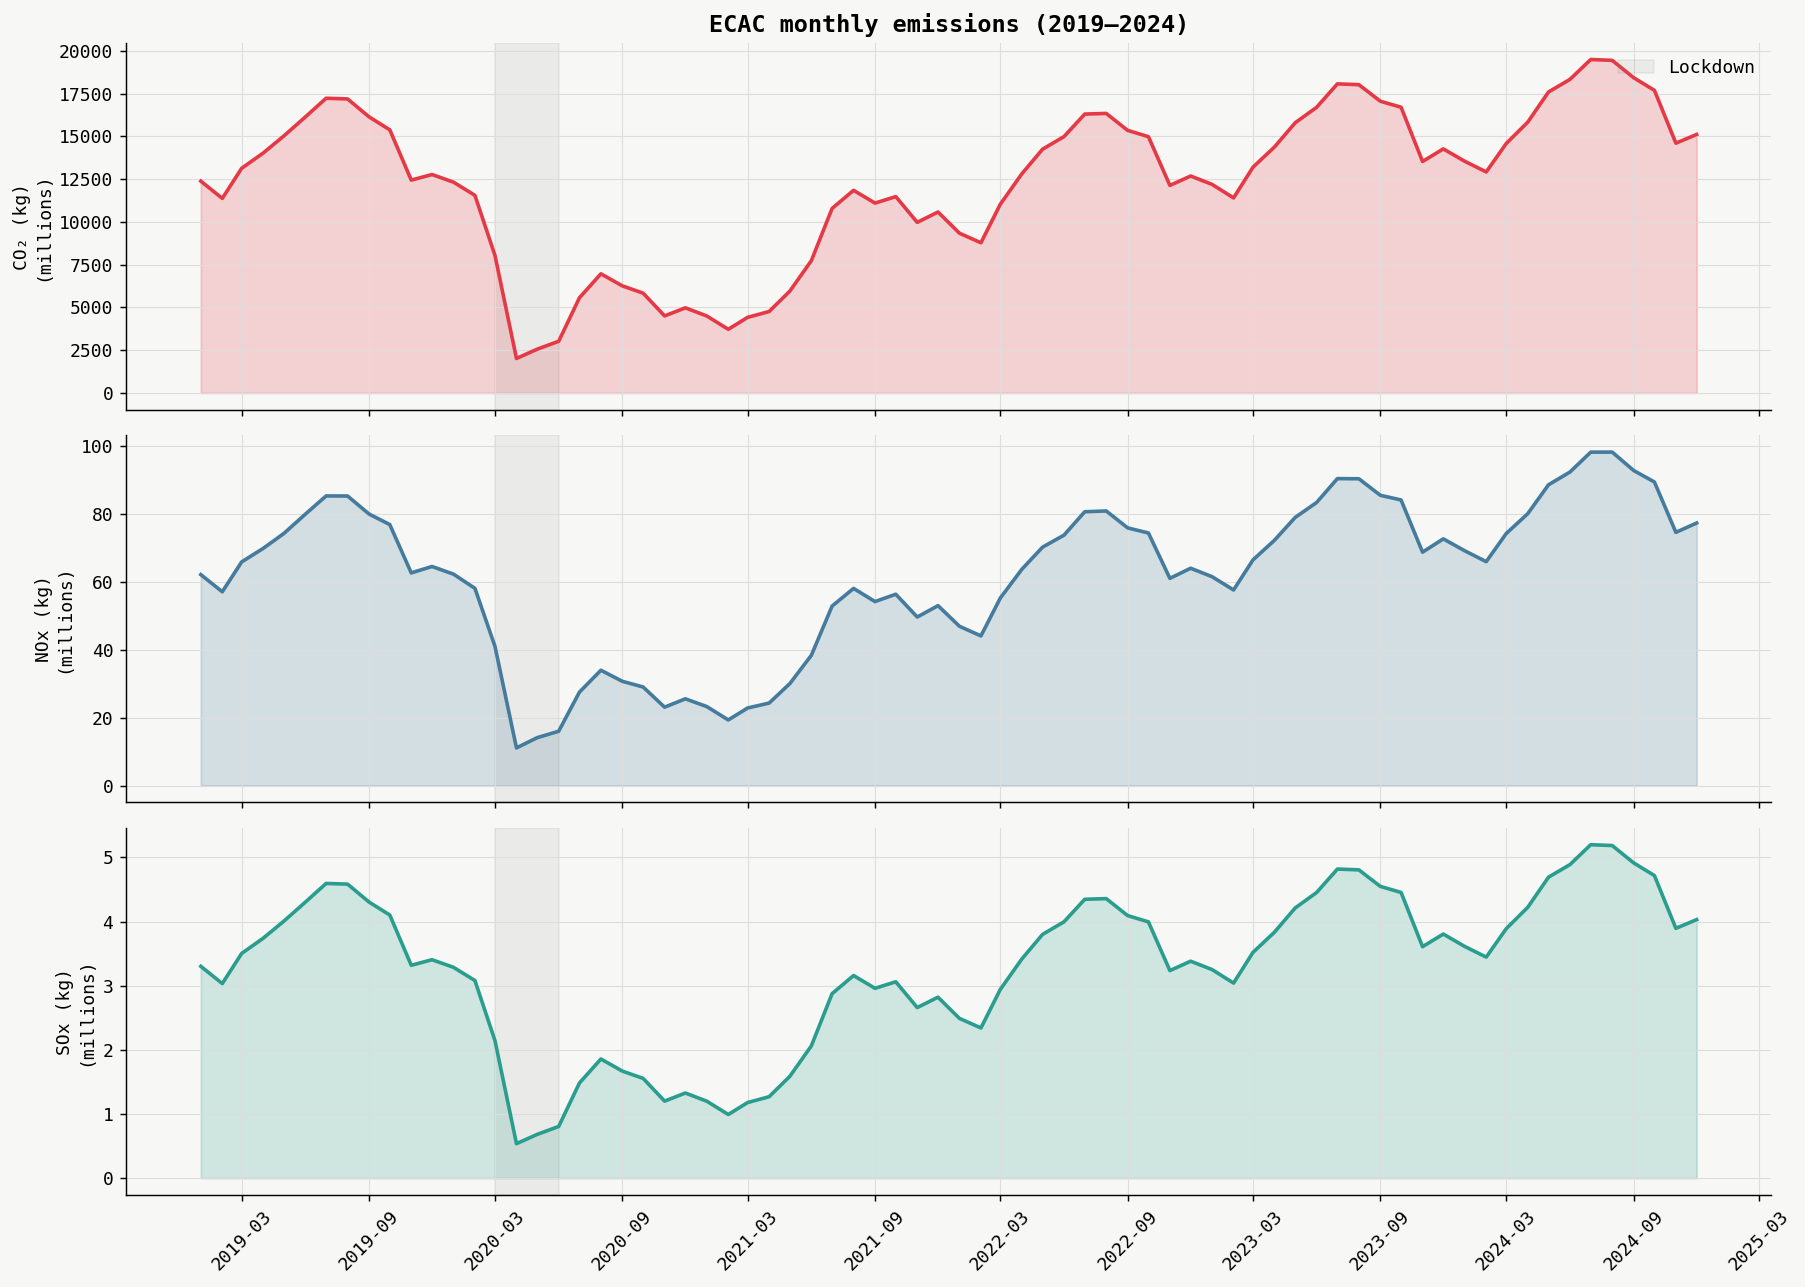

In [44]:
ecac = df_net[df_net["AREA"] == "ECAC"].copy()
ecac_monthly = ecac.groupby("DATE")[["NB_FLIGHTS","CO2_KG","NOX_KG","SOX_KG"]].sum().reset_index()
ecac_monthly = ecac_monthly.sort_values("DATE")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
pollutants = [
    ("CO2_KG", "CO\u2082 (kg)",  "#E63946"),
    ("NOX_KG", "NOx (kg)",       "#457B9D"),
    ("SOX_KG", "SOx (kg)",       "#2A9D8F"),
]

for ax, (col, label, color) in zip(axes, pollutants):
    ax.fill_between(ecac_monthly["DATE"], ecac_monthly[col] / 1e6,
                    alpha=0.2, color=color)
    ax.plot(ecac_monthly["DATE"], ecac_monthly[col] / 1e6,
            color=color, lw=2)
    ax.set_ylabel(f"{label}\n(millions)")
    ax.axvspan("2020-03-01","2020-06-01", alpha=0.1, color="grey", label="Lockdown")
    if ax == axes[0]:
        ax.set_title("ECAC monthly emissions (2019\u20132024)", fontweight="bold", fontsize=13)
        ax.legend(frameon=False, loc="upper right")

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


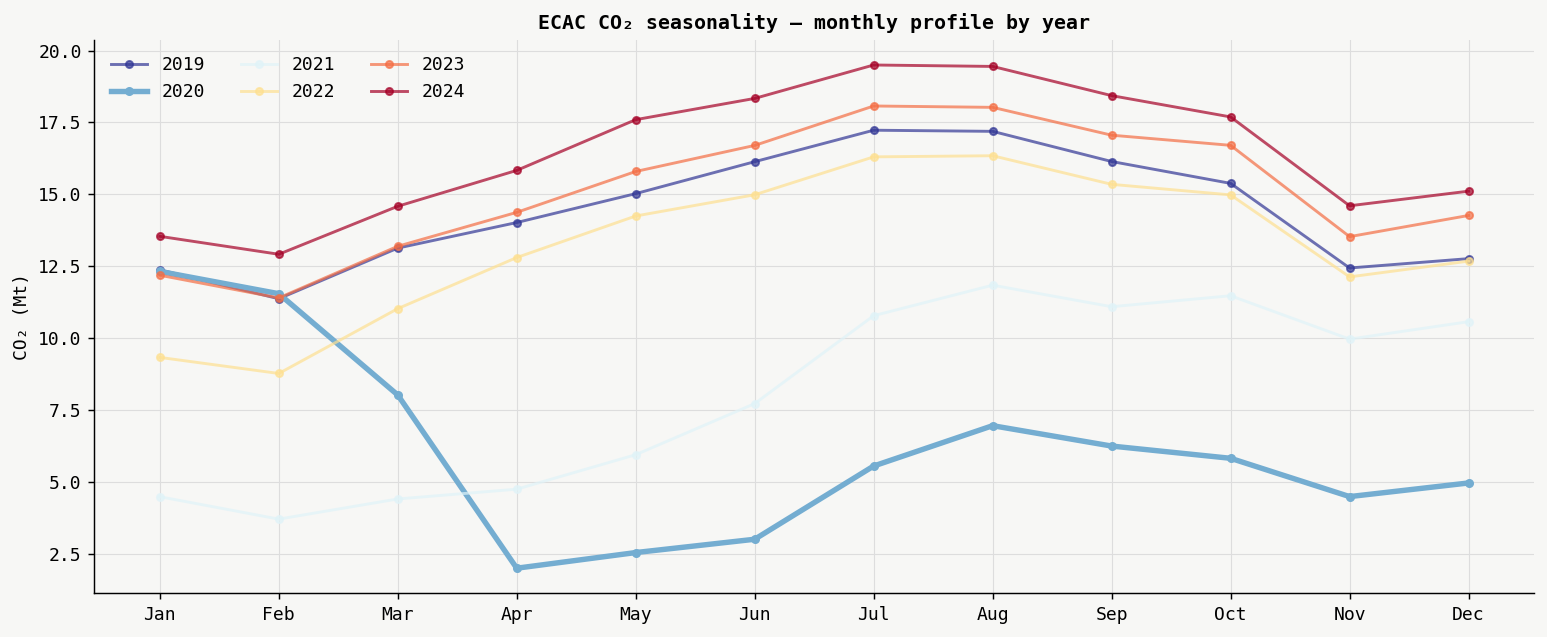

In [45]:
ecac_season = ecac.groupby(["YEAR","MONTH"])["CO2_KG"].sum().reset_index()
piv_season = ecac_season.pivot(index="MONTH", columns="YEAR", values="CO2_KG")

fig, ax = plt.subplots(figsize=(12, 5))
palette_yr = cm.get_cmap("RdYlBu_r", len(piv_season.columns))
for i, yr in enumerate(piv_season.columns):
    style = {"lw": 3, "alpha": 1.0} if yr == 2020 else {"lw": 1.6, "alpha": 0.7}
    ax.plot(piv_season.index, piv_season[yr] / 1e9, marker="o", ms=4,
            color=palette_yr(i), label=str(yr), **style)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                     "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_ylabel("CO\u2082 (Mt)")
ax.set_title("ECAC CO\u2082 seasonality \u2014 monthly profile by year", fontweight="bold")
ax.legend(ncol=3, frameon=False)
plt.tight_layout()
plt.show()


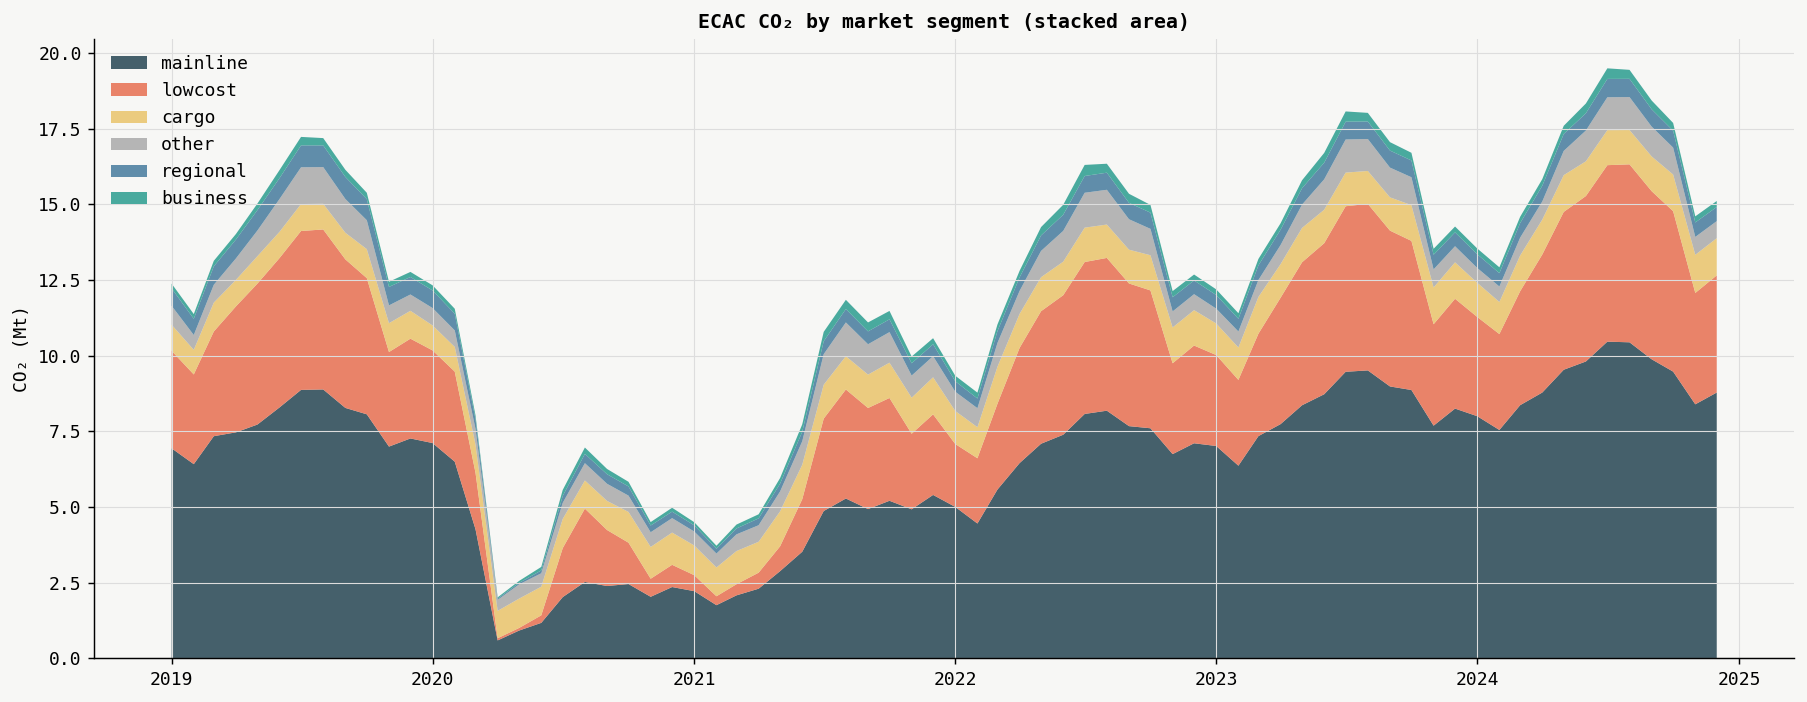

In [46]:
seg = df_net[df_net["AREA"] == "ECAC"].groupby(
    ["DATE","MARKET_SEGMENT"]
)["CO2_KG"].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5.5))
seg_piv = seg.pivot(index="DATE", columns="MARKET_SEGMENT", values="CO2_KG").fillna(0) / 1e9
order = seg_piv.sum().sort_values(ascending=False).index
colors_seg = {"mainline":"#264653","lowcost":"#E76F51","business":"#2A9D8F",
              "cargo":"#E9C46A","regional":"#457B9D","other":"#AAAAAA"}
ax.stackplot(seg_piv.index, *[seg_piv[c] for c in order],
             labels=order, colors=[colors_seg.get(c,"#999") for c in order], alpha=0.85)
ax.set_ylabel("CO\u2082 (Mt)")
ax.set_title("ECAC CO\u2082 by market segment (stacked area)", fontweight="bold")
ax.legend(loc="upper left", frameon=False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()


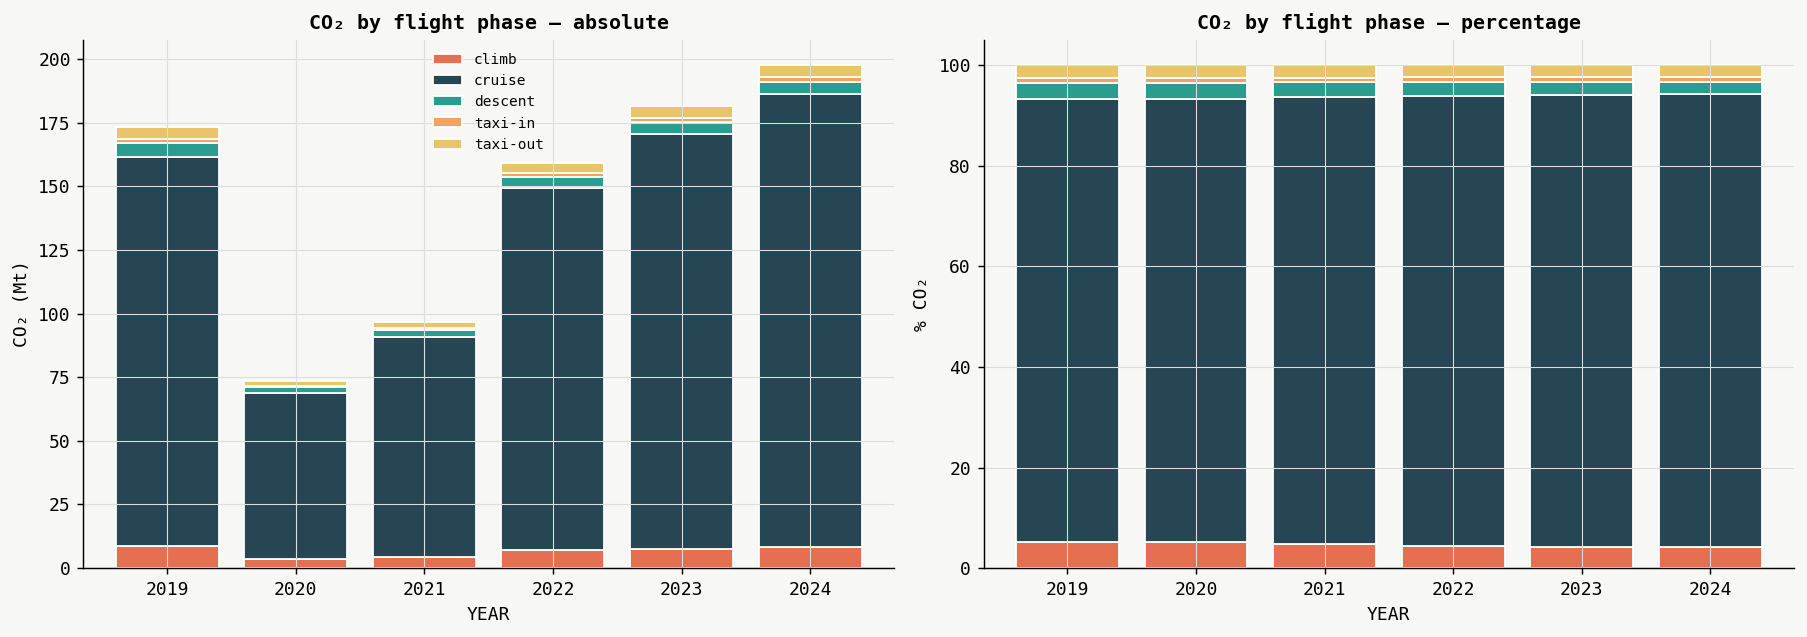

In [47]:
phase = df_net[df_net["AREA"] == "ECAC"].groupby(
    ["YEAR","FLIGHT_PHASE"]
)["CO2_KG"].sum().reset_index()

phase_piv = phase.pivot(index="YEAR", columns="FLIGHT_PHASE", values="CO2_KG") / 1e9
phase_pct = phase_piv.div(phase_piv.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_ph = {"cruise":"#264653","climb":"#E76F51","descent":"#2A9D8F",
             "taxi-out":"#E9C46A","taxi-in":"#F4A261"}

# Absolute
phase_piv.plot(kind="bar", stacked=True, ax=axes[0],
               color=[colors_ph.get(c,"#999") for c in phase_piv.columns],
               edgecolor="white", width=0.8)
axes[0].set_ylabel("CO\u2082 (Mt)")
axes[0].set_title("CO\u2082 by flight phase \u2014 absolute", fontweight="bold")
axes[0].legend(fontsize=8, frameon=False)
axes[0].tick_params(axis="x", rotation=0)

# Percentage
phase_pct.plot(kind="bar", stacked=True, ax=axes[1],
               color=[colors_ph.get(c,"#999") for c in phase_pct.columns],
               edgecolor="white", width=0.8, legend=False)
axes[1].set_ylabel("% CO\u2082")
axes[1].set_title("CO\u2082 by flight phase \u2014 percentage", fontweight="bold")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


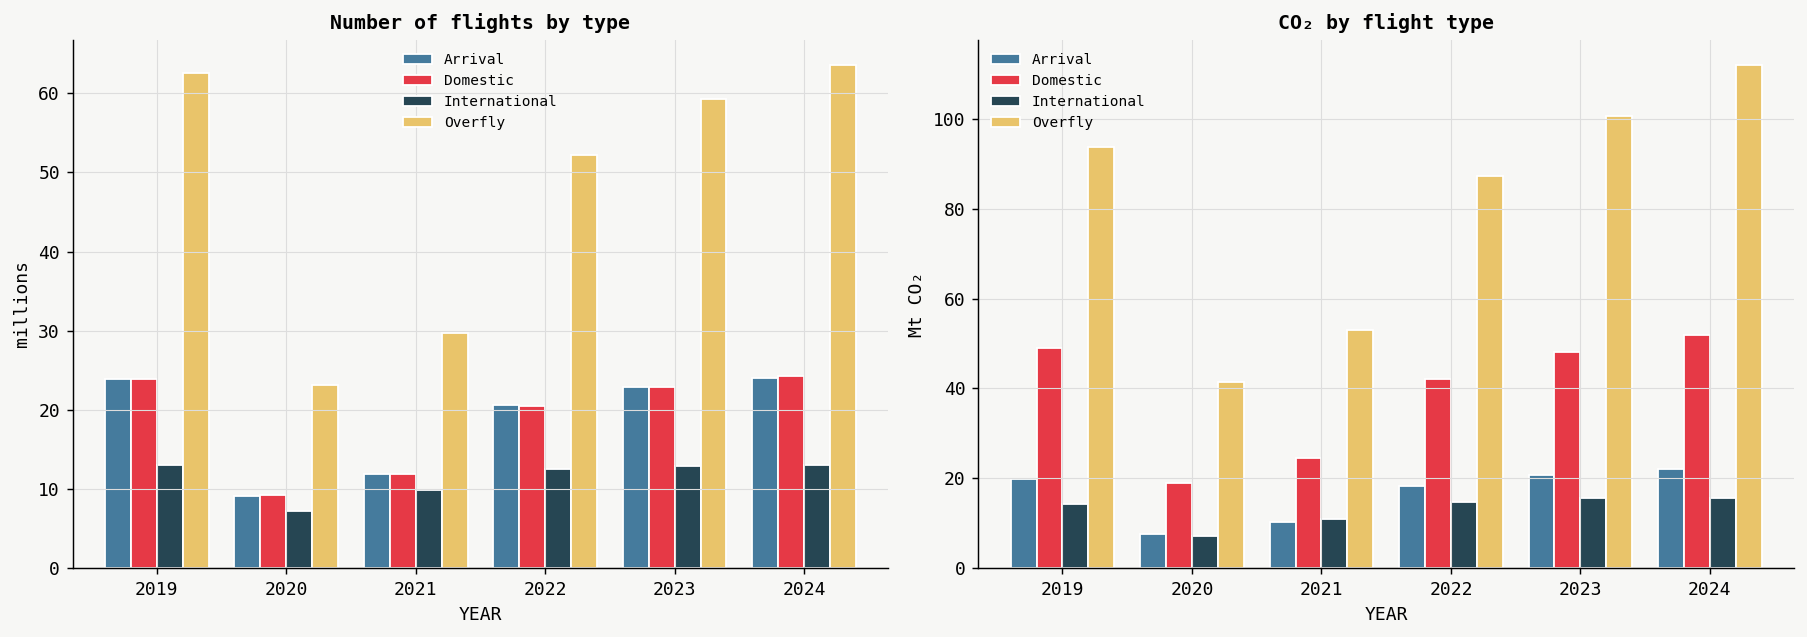

In [48]:
ft_labels = {"D":"Domestic","A":"Arrival","I":"International","O":"Overfly"}
ft = df_state.groupby(["YEAR","FLIGHT_TYPE"])[["CO2_KG","NB_FLIGHTS"]].sum().reset_index()
ft["label"] = ft["FLIGHT_TYPE"].map(ft_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_ft = {"Domestic":"#E63946","Arrival":"#457B9D","International":"#264653","Overfly":"#E9C46A"}

for ax, metric, title in zip(axes,
    ["NB_FLIGHTS","CO2_KG"],
    ["Number of flights by type","CO\u2082 by flight type"]):
    piv = ft.pivot(index="YEAR", columns="label", values=metric)
    divisor = 1e9 if metric == "CO2_KG" else 1e6
    piv = piv / divisor
    piv.plot(kind="bar", ax=ax, color=[colors_ft[c] for c in piv.columns],
             edgecolor="white", width=0.8)
    unit = "Mt CO\u2082" if metric == "CO2_KG" else "millions"
    ax.set_ylabel(unit)
    ax.set_title(title, fontweight="bold")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()


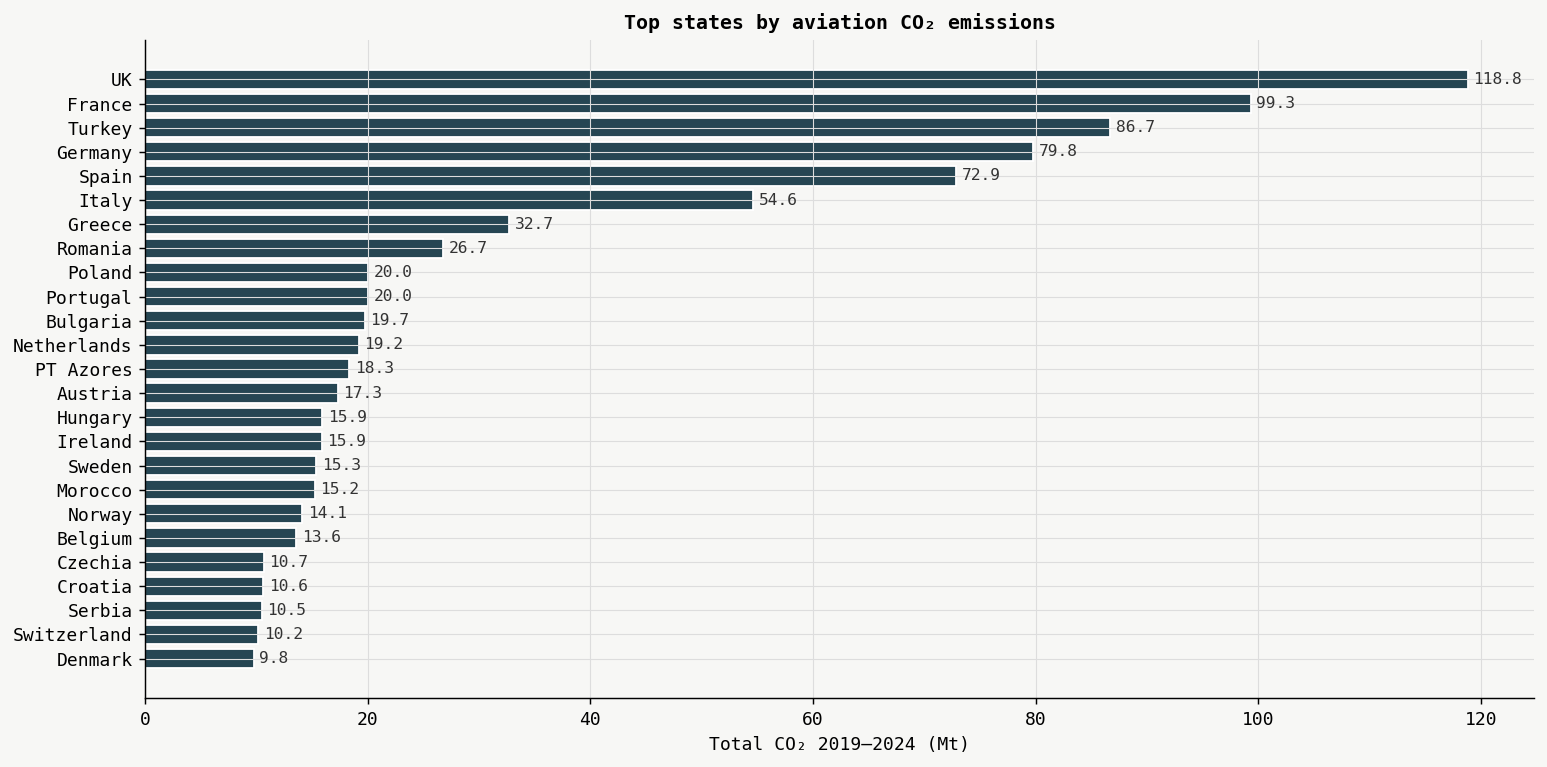

In [49]:
state_tot = (
    df_state.groupby("AREA")["CO2_KG"].sum()
    .reset_index()
    .sort_values("CO2_KG", ascending=False)
    .head(25)
)
state_tot["name"] = state_tot["AREA"].map(CODE2NAME).fillna(state_tot["AREA"])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(state_tot["name"], state_tot["CO2_KG"] / 1e9,
               color="#264653", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Total CO\u2082 2019\u20132024 (Mt)")
ax.set_title("Top states by aviation CO\u2082 emissions", fontweight="bold")

# Annotate values
for bar, val in zip(bars, state_tot["CO2_KG"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val/1e9:.1f}", va="center", fontsize=9, color="#333")

plt.tight_layout()
plt.show()


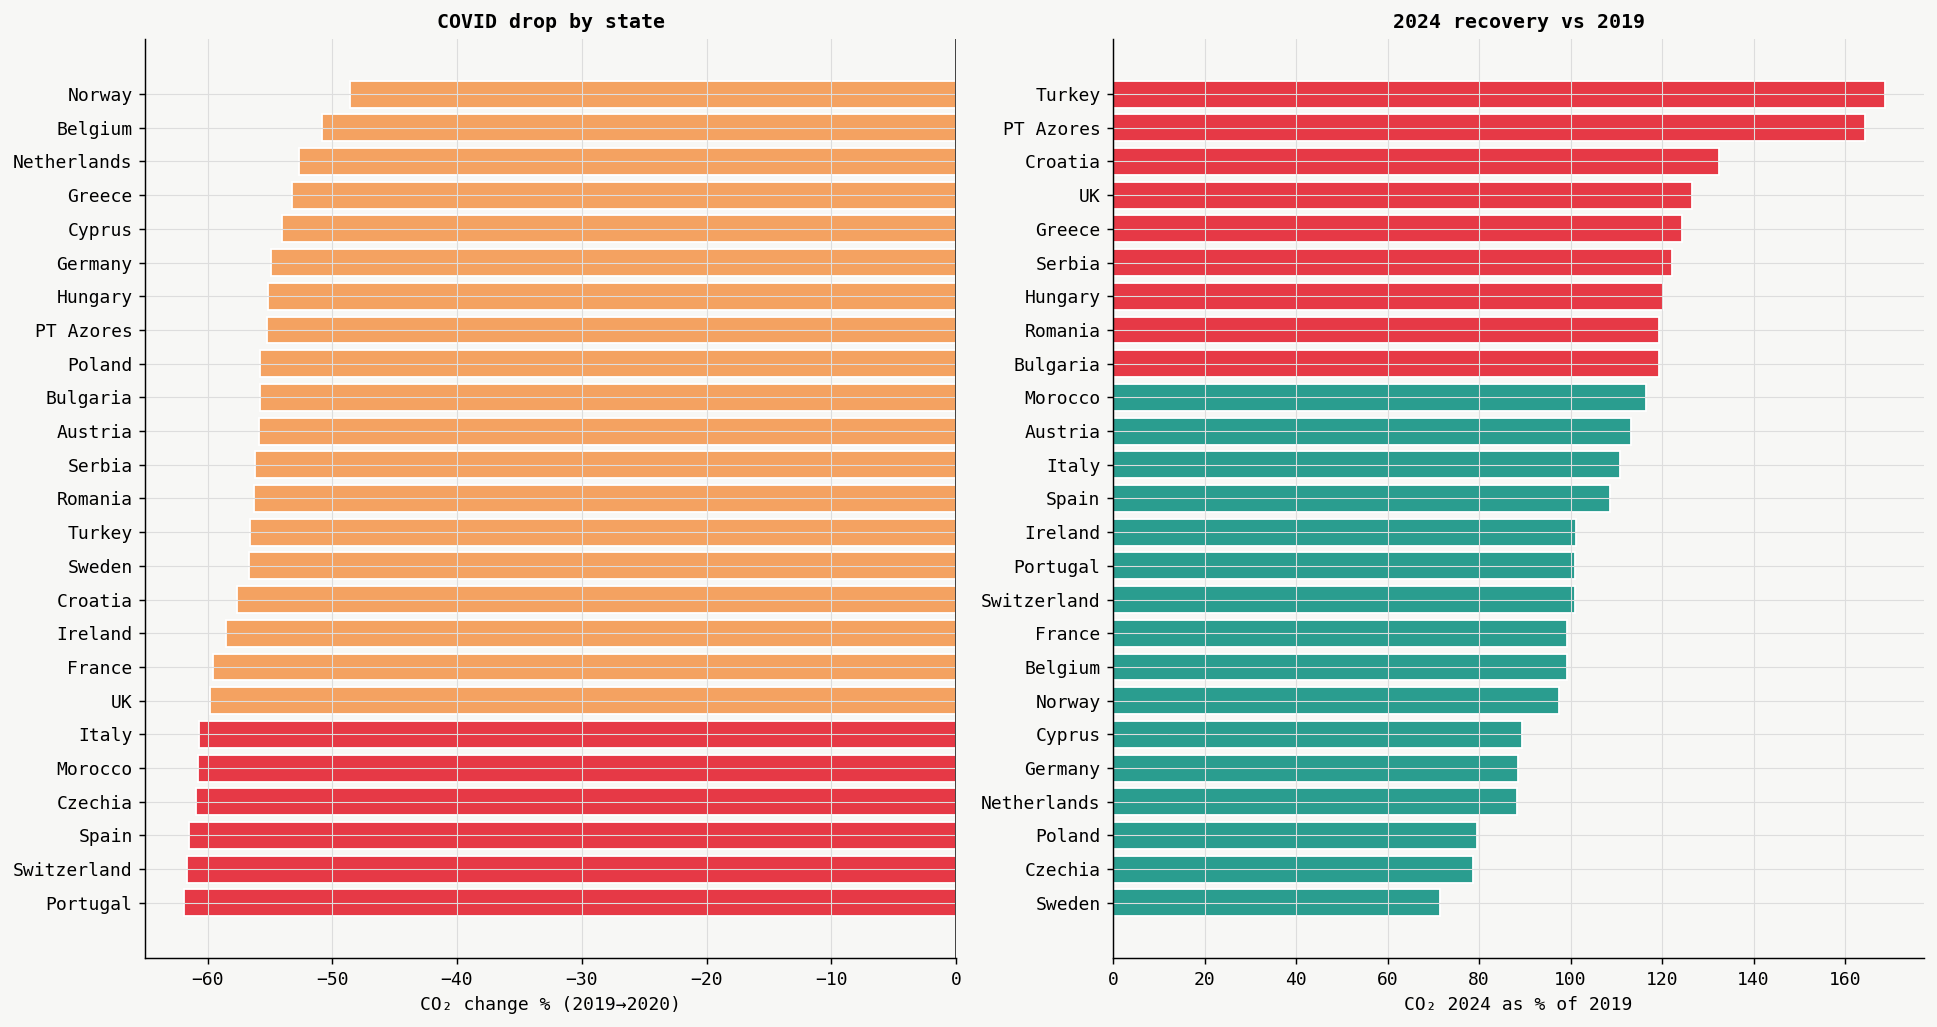

In [50]:
state_yearly = df_state.groupby(["AREA","YEAR"])["CO2_KG"].sum().reset_index()
piv_yr = state_yearly.pivot(index="AREA", columns="YEAR", values="CO2_KG")

# 2019\u21922020 drop
piv_yr["covid_drop"] = (piv_yr[2020] - piv_yr[2019]) / piv_yr[2019] * 100
# 2024 recovery vs 2019
piv_yr["recovery_24"] = piv_yr[2024] / piv_yr[2019] * 100

piv_yr = piv_yr.dropna(subset=["covid_drop","recovery_24"])
piv_yr["name"] = piv_yr.index.map(CODE2NAME)

# Top 25 by volume only
top25_areas = piv_yr[[2019]].nlargest(25, 2019).index
piv_top = piv_yr.loc[top25_areas].sort_values("covid_drop")

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# COVID drop
axes[0].barh(piv_top["name"], piv_top["covid_drop"],
             color=["#E63946" if v < -60 else "#F4A261" if v < -40 else "#2A9D8F"
                    for v in piv_top["covid_drop"]],
             edgecolor="white")
axes[0].axvline(0, color="#333", lw=1)
axes[0].set_xlabel("CO\u2082 change % (2019\u21922020)")
axes[0].set_title("COVID drop by state", fontweight="bold")

# Recovery 2024
piv_top_r = piv_top.sort_values("recovery_24", ascending=True)
axes[1].barh(piv_top_r["name"], piv_top_r["recovery_24"],
             color=["#E63946" if v > 118 else "#2A9D8F"
                    for v in piv_top_r["recovery_24"]],
             edgecolor="white")
axes[1].set_xlabel("CO\u2082 2024 as % of 2019")
axes[1].set_title("2024 recovery vs 2019", fontweight="bold")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()


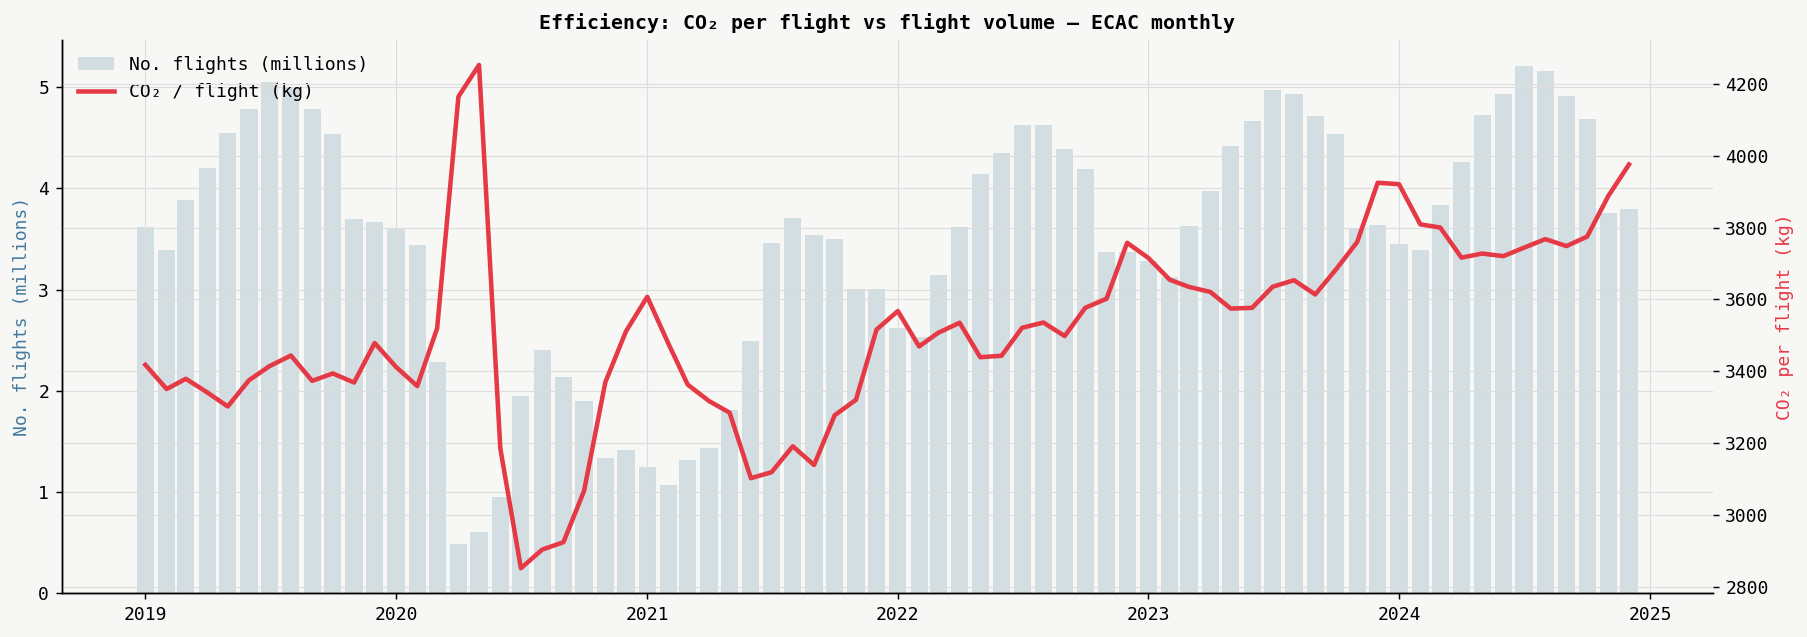

In [51]:
ecac_eff = ecac.groupby("DATE")[["CO2_KG","NB_FLIGHTS"]].sum().reset_index()
ecac_eff["co2_per_flight_kg"] = ecac_eff["CO2_KG"] / ecac_eff["NB_FLIGHTS"]
ecac_eff = ecac_eff.sort_values("DATE")

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(ecac_eff["DATE"], ecac_eff["NB_FLIGHTS"] / 1e6,
        width=25, color="#AEC6CF", alpha=0.5, label="No. flights (millions)")
ax2.plot(ecac_eff["DATE"], ecac_eff["co2_per_flight_kg"],
         color="#E63946", lw=2.5, label="CO\u2082 / flight (kg)")

ax1.set_ylabel("No. flights (millions)", color="#457B9D")
ax2.set_ylabel("CO\u2082 per flight (kg)", color="#E63946")
ax1.set_title("Efficiency: CO\u2082 per flight vs flight volume \u2014 ECAC monthly",
              fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=False)

plt.tight_layout()
plt.show()


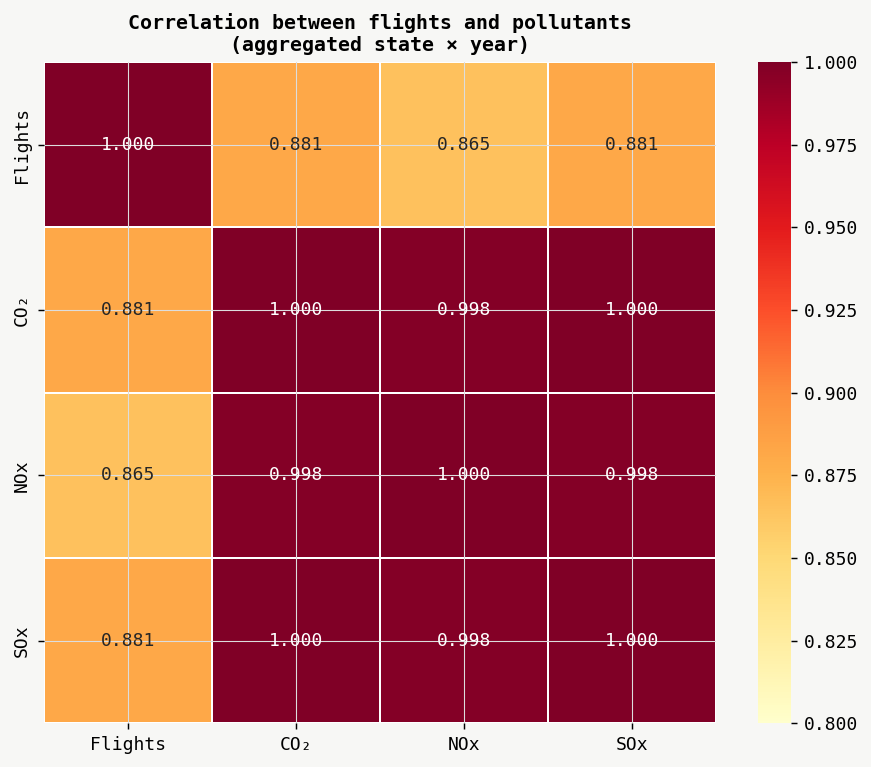

In [52]:
corr_data = df_state.groupby(["AREA","YEAR"])[
    ["NB_FLIGHTS","CO2_KG","NOX_KG","SOX_KG"]
].sum().reset_index()

fig, ax = plt.subplots(figsize=(7, 6))
corr_matrix = corr_data[["NB_FLIGHTS","CO2_KG","NOX_KG","SOX_KG"]].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="YlOrRd",
            vmin=0.8, vmax=1.0, ax=ax, linewidths=1, linecolor="white",
            xticklabels=["Flights","CO\u2082","NOx","SOx"],
            yticklabels=["Flights","CO\u2082","NOx","SOx"])
ax.set_title("Correlation between flights and pollutants\n(aggregated state \u00d7 year)",
             fontweight="bold")
plt.tight_layout()
plt.show()


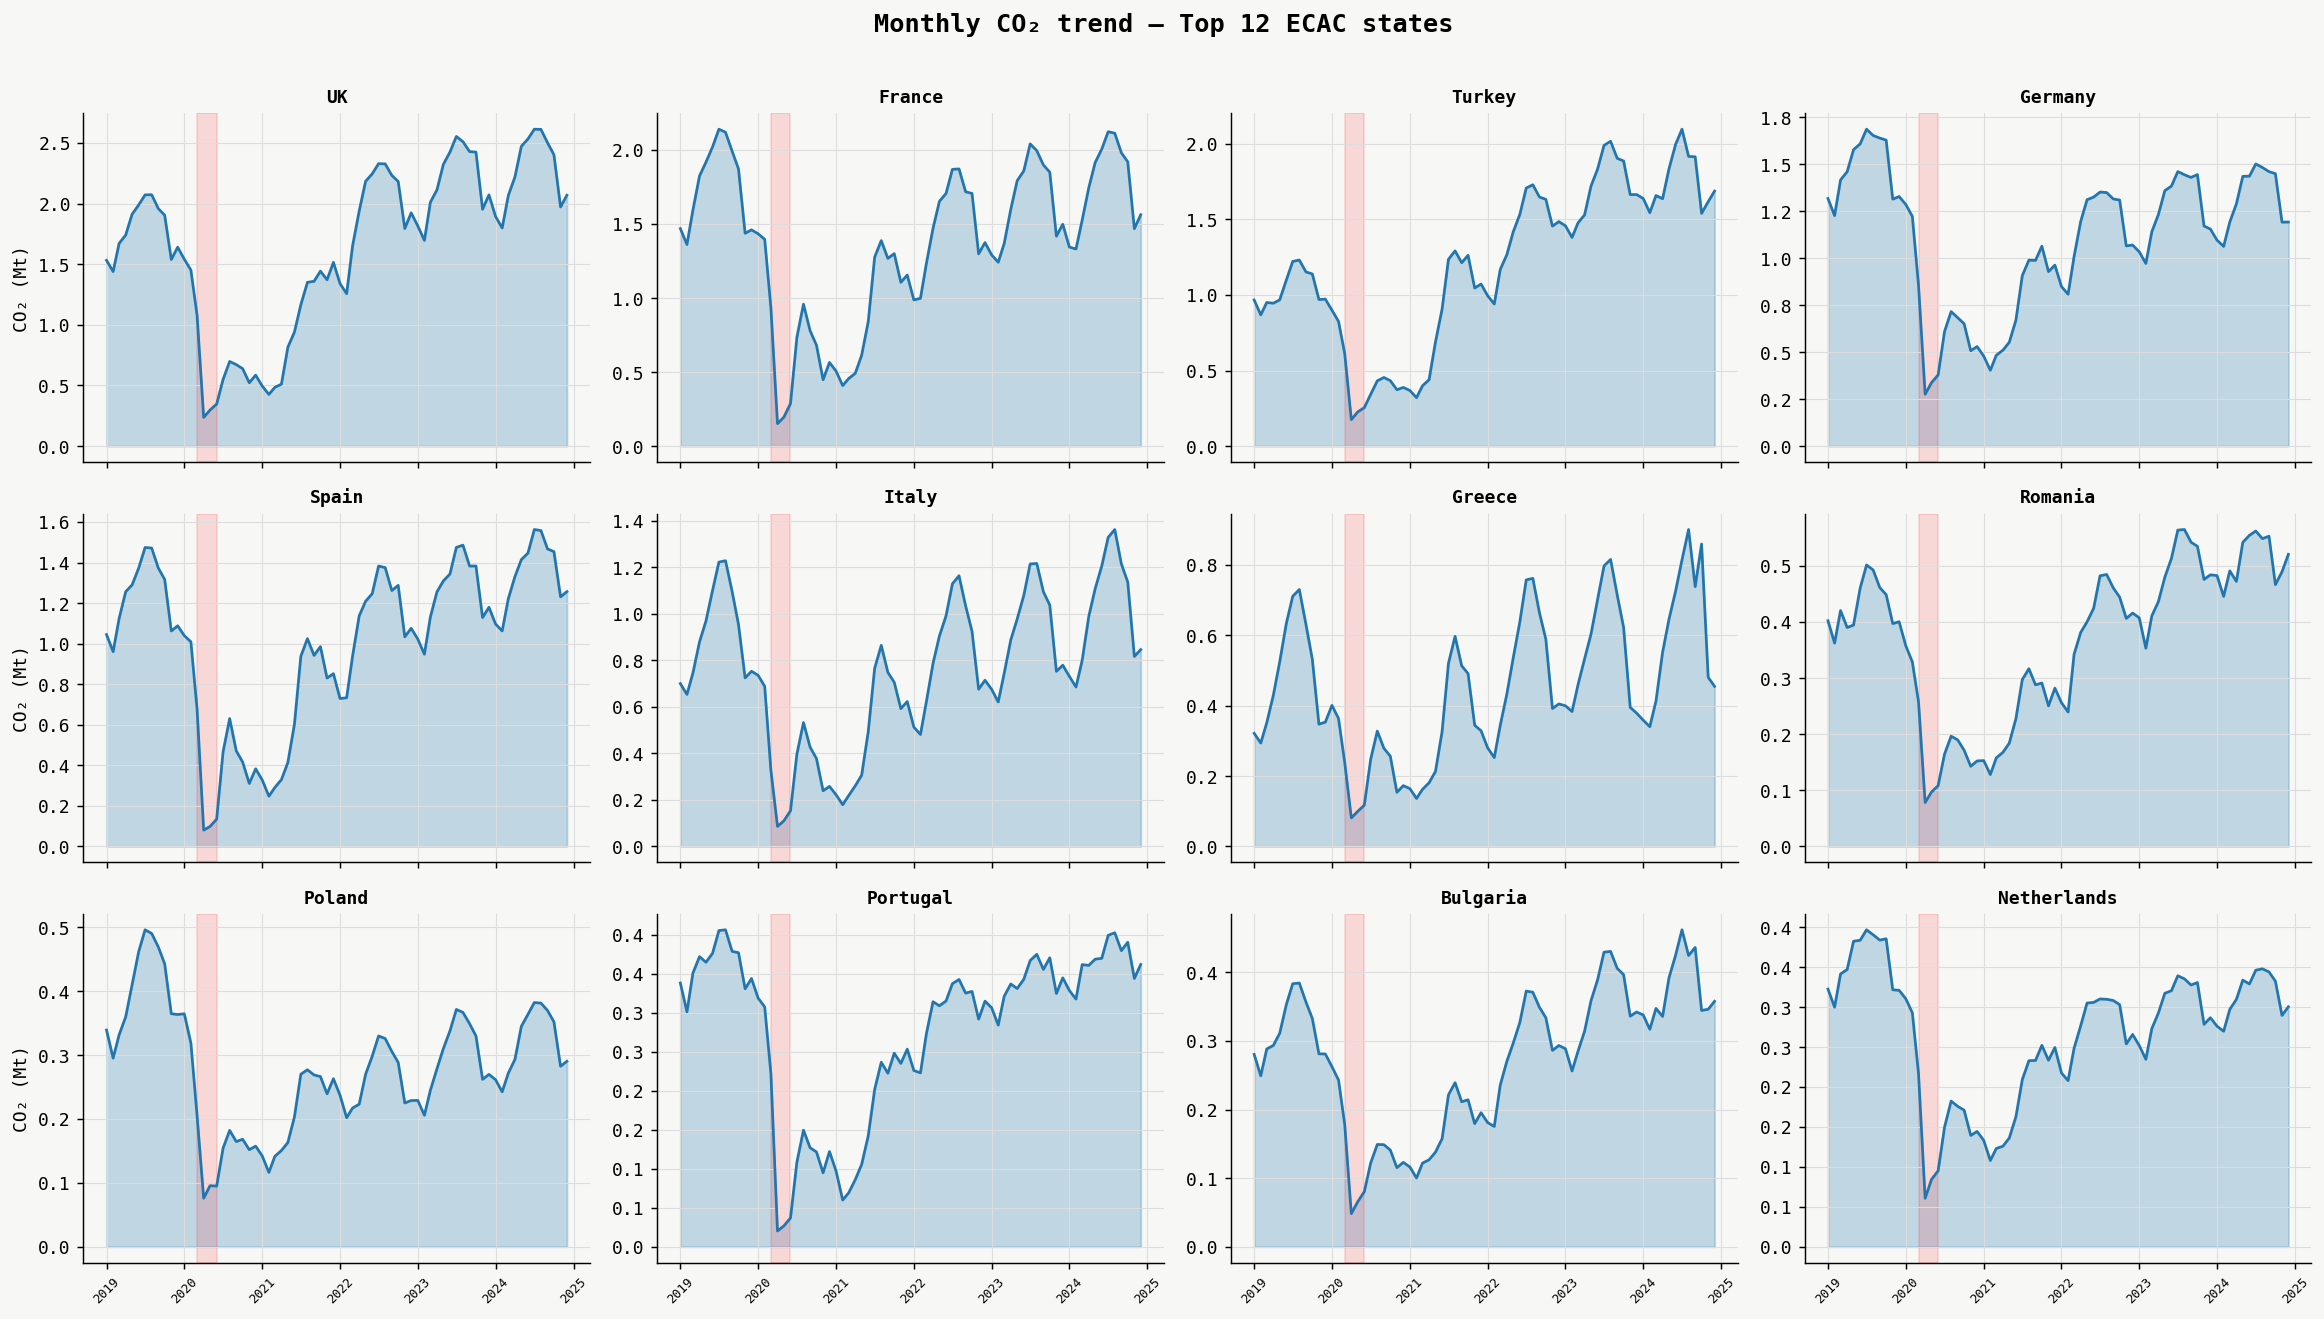

In [53]:
top12 = (
    df_state.groupby("AREA")["CO2_KG"].sum()
    .nlargest(12).index.tolist()
)

sm_data = (
    df_state[df_state["AREA"].isin(top12)]
    .groupby(["AREA","DATE"])["CO2_KG"].sum().reset_index()
)

fig, axes = plt.subplots(3, 4, figsize=(18, 10), sharex=True, sharey=False)
axes_flat = axes.flatten()

for i, area in enumerate(top12):
    ax = axes_flat[i]
    sub = sm_data[sm_data["AREA"] == area].sort_values("DATE")
    ax.fill_between(sub["DATE"], sub["CO2_KG"] / 1e9, alpha=0.25, color="#2176AE")
    ax.plot(sub["DATE"], sub["CO2_KG"] / 1e9, color="#2176AE", lw=1.5)
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-06-01"),
               alpha=0.12, color="red")
    ax.set_title(CODE2NAME.get(area, area), fontweight="bold", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    if i % 4 == 0:
        ax.set_ylabel("CO\u2082 (Mt)")

for ax in axes_flat:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis="x", rotation=45, labelsize=7)

fig.suptitle("Monthly CO\u2082 trend \u2014 Top 12 ECAC states", fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
